In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing & modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Advanced models
import lightgbm as lgb
import xgboost as xgb

# Configuration
warnings.filterwarnings('ignore')
RANDOM_STATE = 50
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(" Environment configured successfully")
print(f"Random State: {RANDOM_STATE}")

 Environment configured successfully
Random State: 50


In [3]:
# Dynamically discover Kaggle input files
import os

print("Kaggle Input Structure:")
print("=" * 70)
for dirname, _, filenames in os.walk(r'D:\Mini-Project'):
    for filename in filenames:
        if filename.endswith(('.csv','.xlsx')):
            filepath = os.path.join(dirname, filename)
            try:
                file_size = os.path.getsize(filepath) / (1024 * 1024)  # MB
                print(f"  {filepath}")
                print(f"  Size: {file_size:.2f} MB\n")
            except:
                print(f"  {filepath}\n")

Kaggle Input Structure:
  D:\Mini-Project\2026-04-04T06-04_export.csv
  Size: 0.00 MB

  D:\Mini-Project\carbon_dataset_1.csv
  Size: 0.01 MB

  D:\Mini-Project\personal_carbon_footprint_behavior.csv
  Size: 0.08 MB



In [4]:
# Load dataset
data_path = 'D:/Mini-Project/personal_carbon_footprint_behavior.csv'
df_raw = pd.read_csv(data_path)

print(f" Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f" Unique users: {df_raw['user_id'].nunique()}")
print(f" Records per user: {df_raw.shape[0] / df_raw['user_id'].nunique():.1f} days average")

 Dataset loaded: 1,400 rows × 12 columns
 Unique users: 200
 Records per user: 7.0 days average


In [5]:
print("\n Dataset Overview:")
print("=" * 70)
df_raw.info()

print("\n" + "=" * 70)
print("\n First 5 Rows:")
df_raw.head()


 Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   str    
 2   transport_mode       1400 non-null   str    
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   str    
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 159.1 KB


 First 5 Rows:


,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


In [6]:
print("\n Statistical Summary:")
print("=" * 70)
df_raw.describe().T


 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
user_id,1400.0,100.500000,57.754936,1.00,50.7500,100.500,150.25,200.00
distance_km,1400.0,9.106071,4.734692,0.50,5.6625,9.180,12.51,22.67
electricity_kwh,1400.0,5.951443,1.993266,2.00,4.5300,5.925,7.29,12.27
renewable_usage_pct,1400.0,31.589286,30.598496,0.00,0.0000,25.000,50.00,100.00
screen_time_hours,1400.0,5.521786,2.018918,2.00,3.8000,5.550,7.30,9.00
waste_generated_kg,1400.0,0.703200,0.236415,0.10,0.5500,0.705,0.86,1.51
eco_actions,1400.0,1.144286,1.019066,0.00,0.0000,1.000,2.00,5.00
carbon_footprint_kg,1400.0,7.980236,2.657858,1.79,6.0800,7.835,9.83,16.02


In [7]:
# Create working copy
df = df_raw.copy()

# Inspect schema
print("\n Dataset Schema:")
print("=" * 70)
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    missing = df[col].isnull().sum()
    print(f"{i:2d}. {col:25s} | Type: {str(dtype):10s} | Unique: {unique:4d} | Missing: {missing}")


 Dataset Schema:
 1. user_id                   | Type: int64      | Unique:  200 | Missing: 0
 2. day_type                  | Type: str        | Unique:    2 | Missing: 0
 3. transport_mode            | Type: str        | Unique:    5 | Missing: 0
 4. distance_km               | Type: float64    | Unique:  933 | Missing: 0
 5. electricity_kwh           | Type: float64    | Unique:  632 | Missing: 0
 6. renewable_usage_pct       | Type: int64      | Unique:    5 | Missing: 0
 7. food_type                 | Type: str        | Unique:    3 | Missing: 0
 8. screen_time_hours         | Type: float64    | Unique:   71 | Missing: 0
 9. waste_generated_kg        | Type: float64    | Unique:  125 | Missing: 0
10. eco_actions               | Type: int64      | Unique:    6 | Missing: 0
11. carbon_footprint_kg       | Type: float64    | Unique:  765 | Missing: 0
12. carbon_impact_level       | Type: str        | Unique:    3 | Missing: 0


In [8]:
# Missing values check
missing = df.isnull().sum()
print("\n Missing Values Analysis:")
print("=" * 70)
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print(" No missing values detected!")


 Missing Values Analysis:
 No missing values detected!


In [9]:
# Duplicate check
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

if duplicates > 0:
    print(f"   Removing {duplicates} duplicates...")
    df = df.drop_duplicates()
    print(f"  Dataset shape after deduplication: {df.shape}")


Duplicate Records: 0


In [10]:
print("\n Carbon Impact Level Distribution:")
print("=" * 70)
impact_counts = df['carbon_impact_level'].value_counts()
for level, count in impact_counts.items():
    pct = count / len(df) * 100
    print(f"  {level:10s}: {count:4d} ({pct:5.2f}%)")


 Carbon Impact Level Distribution:
  Medium    :  869 (62.07%)
  Low       :  337 (24.07%)
  High      :  194 (13.86%)


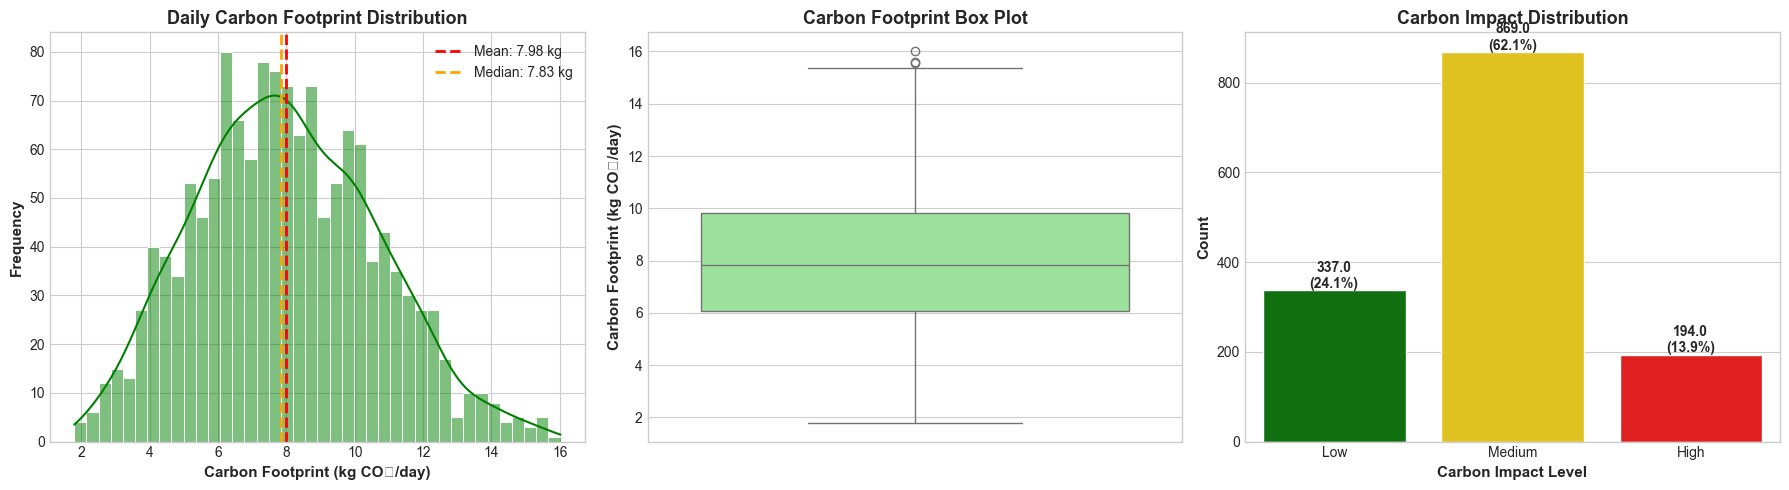

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------
# 1. Histogram (Seaborn)
# -------------------------------
sns.histplot(df['carbon_footprint_kg'], bins=40, kde=True, ax=axes[0], color='green')

# Mean & Median lines
mean_val = df['carbon_footprint_kg'].mean()
median_val = df['carbon_footprint_kg'].median()

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_val:.2f} kg')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=2, 
                label=f'Median: {median_val:.2f} kg')

axes[0].set_xlabel('Carbon Footprint (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Daily Carbon Footprint Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

# -------------------------------
# 2. Box Plot (Seaborn)
# -------------------------------
sns.boxplot(y=df['carbon_footprint_kg'], ax=axes[1], color='lightgreen')

axes[1].set_ylabel('Carbon Footprint (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[1].set_title('Carbon Footprint Box Plot', fontsize=13, fontweight='bold')

# -------------------------------
# 3. Impact Level Bar Chart
# -------------------------------
impact_order = ['Low', 'Medium', 'High']

sns.countplot(data=df, x='carbon_impact_level', order=impact_order,
              palette=['green', 'gold', 'red'], ax=axes[2])

axes[2].set_xlabel('Carbon Impact Level', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2].set_title('Carbon Impact Distribution', fontsize=13, fontweight='bold')

# Add percentage labels
total = len(df)
for p in axes[2].patches:
    height = p.get_height()
    axes[2].text(p.get_x() + p.get_width()/2., height + 5,
                 f'{height}\n({height/total*100:.1f}%)',
                 ha='center', fontweight='bold')

# -------------------------------
# Final Layout
# -------------------------------
plt.tight_layout()
plt.show()

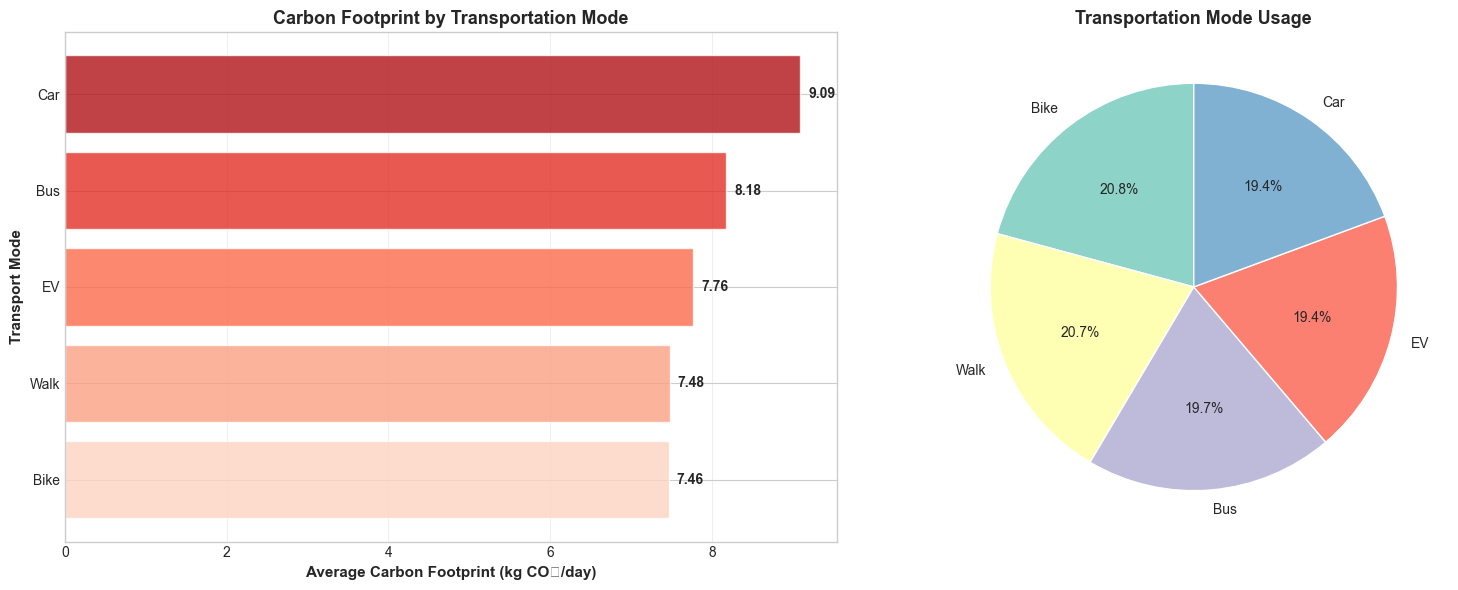

In [12]:
# Transportation analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average carbon by transport mode
transport_carbon = df.groupby('transport_mode')['carbon_footprint_kg'].mean().sort_values(ascending=False)
colors_transport = sns.color_palette('Reds_r', len(transport_carbon))

axes[0].barh(range(len(transport_carbon)), transport_carbon.values, color=colors_transport, alpha=0.8)
axes[0].set_yticks(range(len(transport_carbon)))
axes[0].set_yticklabels(transport_carbon.index)
axes[0].set_xlabel('Average Carbon Footprint (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Transport Mode', fontsize=11, fontweight='bold')
axes[0].set_title('Carbon Footprint by Transportation Mode', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(transport_carbon.values):
    axes[0].text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold')

# Transport mode distribution
transport_counts = df['transport_mode'].value_counts()
axes[1].pie(transport_counts.values, labels=transport_counts.index, 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(transport_counts)))
axes[1].set_title('Transportation Mode Usage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


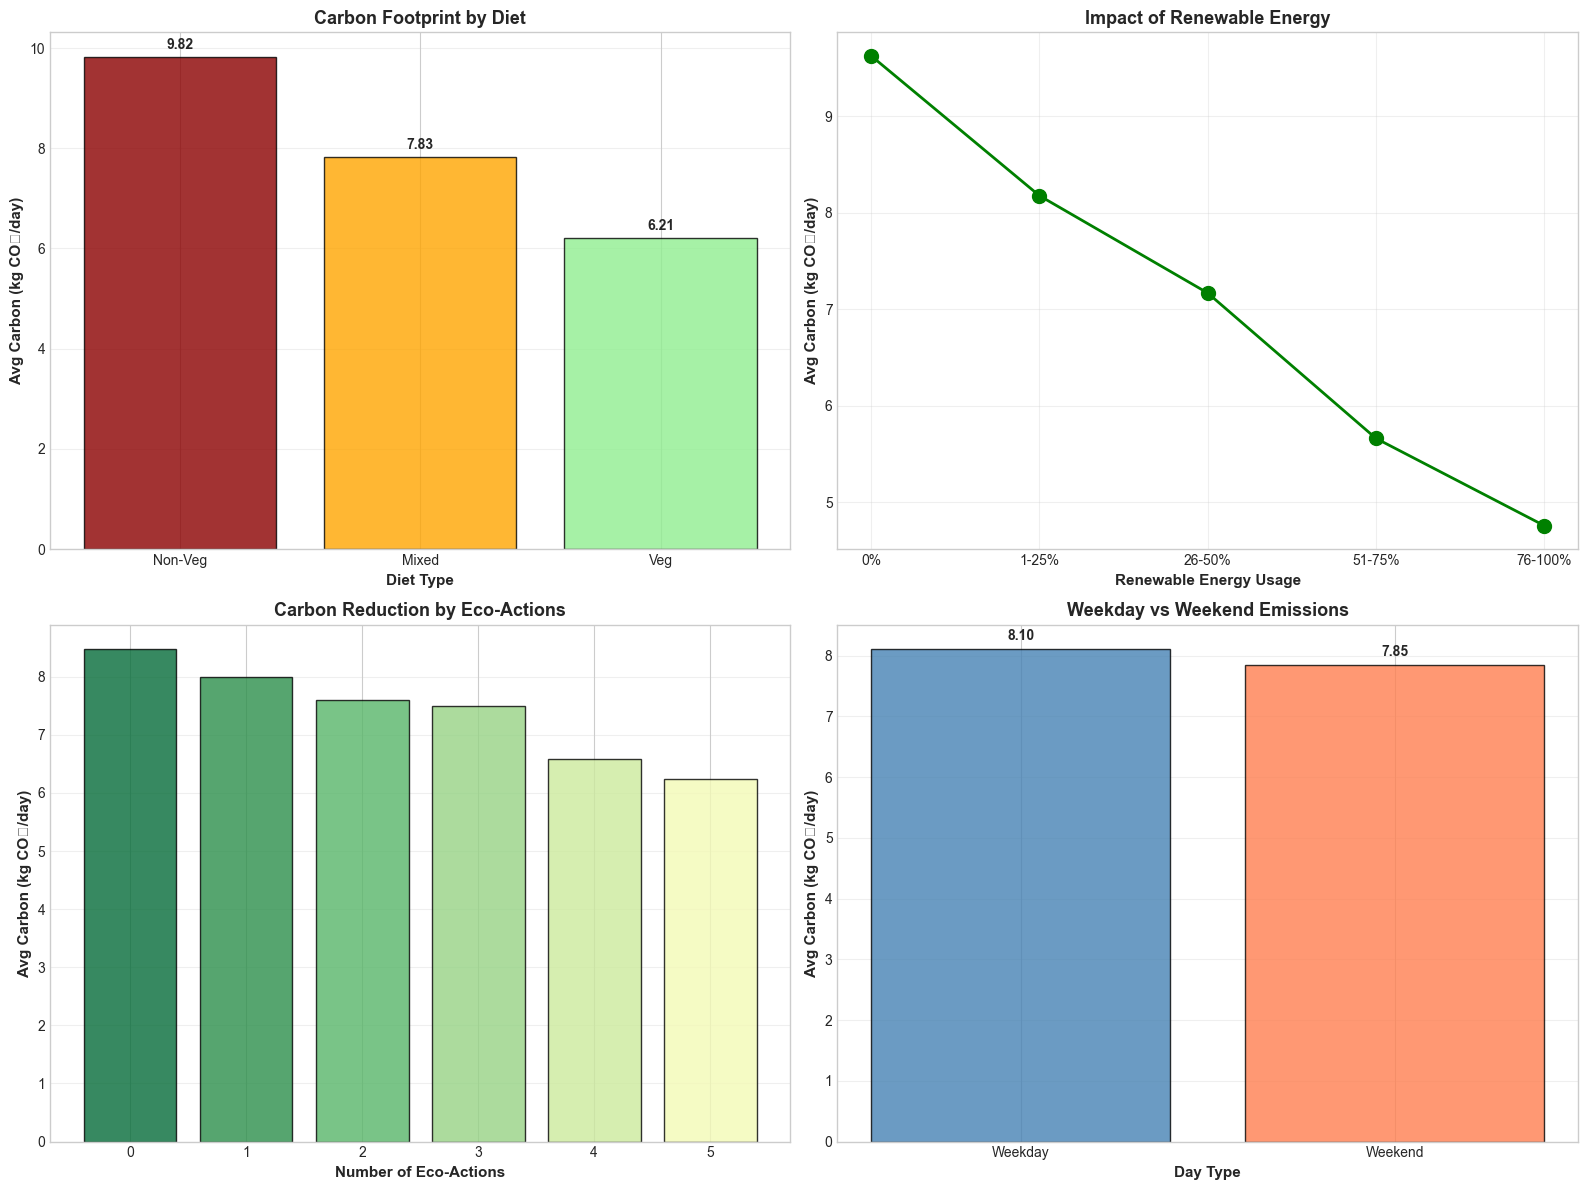

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Diet impact
food_carbon = df.groupby('food_type')['carbon_footprint_kg'].mean().sort_values(ascending=False)
axes[0, 0].bar(food_carbon.index, food_carbon.values, 
               color=['darkred', 'orange', 'lightgreen'], alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Diet Type', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Avg Carbon (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Carbon Footprint by Diet', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(food_carbon.values):
    axes[0, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Renewable energy impact
renewable_bins = [0, 25, 50, 75, 100]
df['renewable_category'] = pd.cut(df['renewable_usage_pct'], bins=[-1] + renewable_bins, 
                                   labels=['0%', '1-25%', '26-50%', '51-75%', '76-100%'])
renewable_carbon = df.groupby('renewable_category')['carbon_footprint_kg'].mean()
axes[0, 1].plot(range(len(renewable_carbon)), renewable_carbon.values, 
                marker='o', linewidth=2, markersize=10, color='green')
axes[0, 1].set_xticks(range(len(renewable_carbon)))
axes[0, 1].set_xticklabels(renewable_carbon.index)
axes[0, 1].set_xlabel('Renewable Energy Usage', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Avg Carbon (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Impact of Renewable Energy', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Eco-actions impact
eco_carbon = df.groupby('eco_actions')['carbon_footprint_kg'].mean()
axes[1, 0].bar(eco_carbon.index, eco_carbon.values, 
               color=sns.color_palette('YlGn_r', len(eco_carbon)), alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Number of Eco-Actions', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Avg Carbon (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Carbon Reduction by Eco-Actions', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Weekday vs Weekend
day_carbon = df.groupby('day_type')['carbon_footprint_kg'].mean()
axes[1, 1].bar(day_carbon.index, day_carbon.values, 
               color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Day Type', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Avg Carbon (kg CO₂/day)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Weekday vs Weekend Emissions', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(day_carbon.values):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

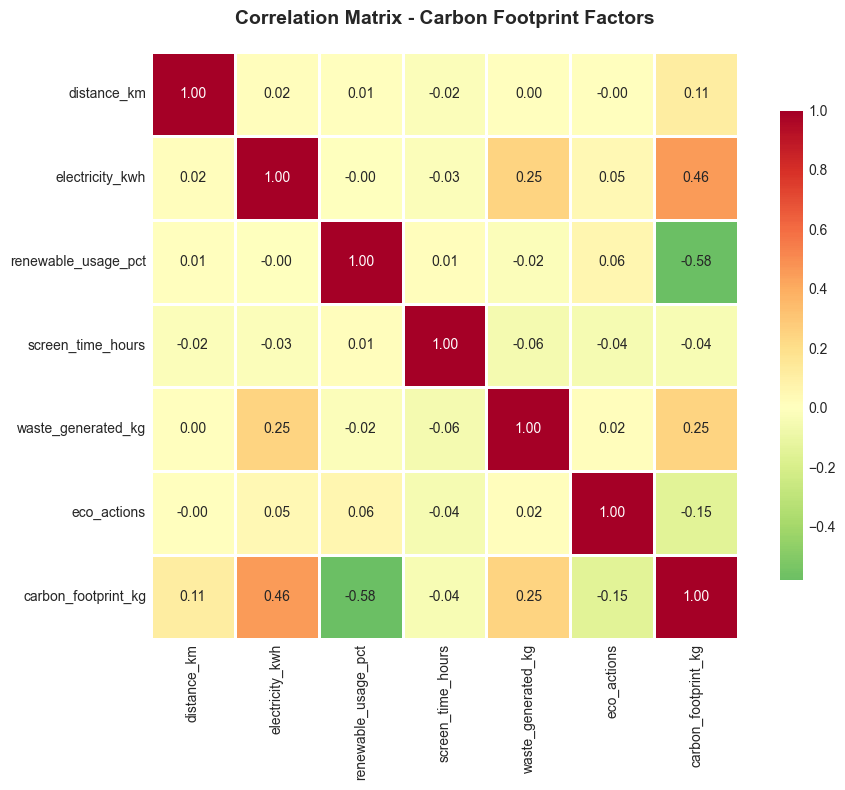


 Feature Correlation with Carbon Footprint:
   electricity_kwh          : +0.462
   waste_generated_kg       : +0.249
   distance_km              : +0.111
   screen_time_hours        : -0.039
   eco_actions              : -0.153
   renewable_usage_pct      : -0.582


In [14]:
numeric_cols = ['distance_km', 'electricity_kwh', 'renewable_usage_pct', 
                'screen_time_hours', 'waste_generated_kg', 'eco_actions', 'carbon_footprint_kg']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Carbon Footprint Factors', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with carbon footprint
carbon_corr = corr_matrix['carbon_footprint_kg'].drop('carbon_footprint_kg').sort_values(ascending=False)
print("\n Feature Correlation with Carbon Footprint:")
print("="*70)
for feat, corr in carbon_corr.items():
    print(f"   {feat:25s}: {corr:+.3f}")


In [15]:
# Create feature engineering copy
df_feat = df.copy()

print("🔧 Applying Sustainability-Focused Feature Engineering...")
print("=" * 70)

feature_count = 0

# 1. Transportation emissions intensity
df_feat['transport_intensity'] = df_feat['distance_km'] * (
    df_feat['transport_mode'].map({
        'Car': 2.0, 'Bus': 0.8, 'EV': 0.3, 'Bike': 0.0, 'Walk': 0.0
    })
)
feature_count += 1

# 2. High-distance travel flag
df_feat['long_distance'] = (df_feat['distance_km'] > 15).astype(int)
feature_count += 1

# 3. Carbon-free transport
df_feat['zero_emission_transport'] = df_feat['transport_mode'].isin(['Walk', 'Bike']).astype(int)
feature_count += 1

# 4. Energy consumption categories
df_feat['energy_level'] = pd.cut(df_feat['electricity_kwh'], 
                                  bins=[0, 4, 7, 100],
                                  labels=['Low', 'Medium', 'High'])
feature_count += 1

# 5. Renewable energy champion
df_feat['renewable_champion'] = (df_feat['renewable_usage_pct'] >= 75).astype(int)
feature_count += 1

# 6. Dirty energy usage
df_feat['dirty_energy_kwh'] = df_feat['electricity_kwh'] * (1 - df_feat['renewable_usage_pct'] / 100)
feature_count += 1

# 7. Diet emissions score
df_feat['diet_score'] = df_feat['food_type'].map({
    'Veg': 0, 'Mixed': 1, 'Non-Veg': 2
})
feature_count += 1

# 8. Screen time category
df_feat['screen_category'] = pd.cut(df_feat['screen_time_hours'], 
                                     bins=[0, 4, 6, 100],
                                     labels=['Low', 'Medium', 'High'])
feature_count += 1

# 9. Excessive screen time
df_feat['excessive_screen'] = (df_feat['screen_time_hours'] > 7).astype(int)
feature_count += 1

# 10. Waste generation level
df_feat['high_waste'] = (df_feat['waste_generated_kg'] > 0.8).astype(int)
feature_count += 1

# 11. Eco-champion flag
df_feat['eco_champion'] = (df_feat['eco_actions'] >= 3).astype(int)
feature_count += 1

# 12. Sustainability score (composite)
df_feat['sustainability_score'] = (
    df_feat['renewable_usage_pct'] / 20 + 
    df_feat['eco_actions'] * 5 - 
    df_feat['diet_score'] * 10 - 
    df_feat['waste_generated_kg'] * 10
)
feature_count += 1

# 13. Weekend behavior
df_feat['is_weekend'] = (df_feat['day_type'] == 'Weekend').astype(int)
feature_count += 1

print(f"\n Created {feature_count} new features")
print(f" Dataset shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} columns")

🔧 Applying Sustainability-Focused Feature Engineering...

 Created 13 new features
 Dataset shape: 1,400 rows × 26 columns


In [16]:
print("\nEncoding categorical features...")
print("=" * 70)

target_col = 'carbon_footprint_kg'

# Identify categorical columns
categorical_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in [target_col, 'carbon_impact_level']]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_feat[f'{col}_encoded'] = le.fit_transform(df_feat[col].astype(str))
    label_encoders[col] = le
    print(f"{col:25s}: {len(le.classes_):2d} unique categories")

# Drop original categorical columns
df_feat = df_feat.drop(columns=categorical_cols + ['carbon_impact_level'])

print(f"\n Encoding complete. Dataset now has {df_feat.shape[1]} columns.")


Encoding categorical features...
day_type                 :  2 unique categories
transport_mode           :  5 unique categories
food_type                :  3 unique categories
renewable_category       :  5 unique categories
energy_level             :  3 unique categories
screen_category          :  3 unique categories

 Encoding complete. Dataset now has 25 columns.


In [17]:
# Prepare target variable
y = df_feat[target_col].copy()

# Remove target and ID from features
cols_to_drop = [target_col, 'user_id']
df_feat = df_feat.drop(columns=[c for c in cols_to_drop if c in df_feat.columns])

print(f"   Target Variable: '{target_col}'")
print(f"   Min: {y.min():.2f} kg CO₂/day")
print(f"   Max: {y.max():.2f} kg CO₂/day")
print(f"   Mean: {y.mean():.2f} kg CO₂/day")
print(f"   Median: {y.median():.2f} kg CO₂/day")

print(f"\n Target prepared: {len(y):,} samples")
print(f" Feature matrix: {df_feat.shape[1]} features")

   Target Variable: 'carbon_footprint_kg'
   Min: 1.79 kg CO₂/day
   Max: 16.02 kg CO₂/day
   Mean: 7.98 kg CO₂/day
   Median: 7.83 kg CO₂/day

 Target prepared: 1,400 samples
 Feature matrix: 23 features


In [18]:
# Select numeric features
X = df_feat.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 
                                    'float16', 'float32', 'float64']).copy()

# Handle NaN values if any
if X.isnull().sum().sum() > 0:
    print("\n Handling missing values...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)

print(f"\n Final Feature Matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f" Target Vector: {len(y):,} samples")


 Final Feature Matrix: 1,400 rows × 23 features
 Target Vector: 1,400 samples


In [19]:
# Train-test split (stratified by user to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"   Train-Test Split Complete")
print(f"   Training: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n   Train target - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"   Test target  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

   Train-Test Split Complete
   Training: 1,120 samples (80.0%)
   Testing:  280 samples (20.0%)

   Train target - Mean: 7.97, Std: 2.65
   Test target  - Mean: 8.02, Std: 2.71


In [20]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\n Feature scaling complete (StandardScaler)")


 Feature scaling complete (StandardScaler)


In [21]:
# Evaluation helper function
def evaluate_regressor(model, X_tr, y_tr, X_te, y_te, model_name):
    """
    Comprehensive regressor evaluation
    """
    print(f"\n{'='*70}")
    print(f" Evaluating: {model_name}")
    print(f"{'='*70}")
    
    # Predictions
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Metrics
    train_r2 = r2_score(y_tr, y_train_pred)
    test_r2 = r2_score(y_te, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_te, y_test_pred))
    
    train_mae = mean_absolute_error(y_tr, y_train_pred)
    test_mae = mean_absolute_error(y_te, y_test_pred)
    
    print(f"\n Performance Metrics:")
    print(f"   Train R²:      {train_r2:.4f}")
    print(f"   Test R²:       {test_r2:.4f}")
    print(f"   Train RMSE:    {train_rmse:.2f} kg CO₂")
    print(f"   Test RMSE:     {test_rmse:.2f} kg CO₂")
    print(f"   Train MAE:     {train_mae:.2f} kg CO₂")
    print(f"   Test MAE:      {test_mae:.2f} kg CO₂")
    
    # Prediction vs Actual plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='steelblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Carbon (kg CO₂)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Predicted Carbon (kg CO₂)', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Predicted vs Actual - {model_name}', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    
    # Residuals plot
    residuals = y_test - y_test_pred
    axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30, color='coral')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Carbon (kg CO₂)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Residuals (kg CO₂)', fontsize=11, fontweight='bold')
    axes[1].set_title(f'Residual Plot - {model_name}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model_name': model_name,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'model': model
    }

print(" Evaluation function ready")

 Evaluation function ready


 Training Linear Regression...

 Evaluating: Linear Regression

 Performance Metrics:
   Train R²:      0.9998
   Test R²:       0.9998
   Train RMSE:    0.03 kg CO₂
   Test RMSE:     0.04 kg CO₂
   Train MAE:     0.03 kg CO₂
   Test MAE:      0.03 kg CO₂


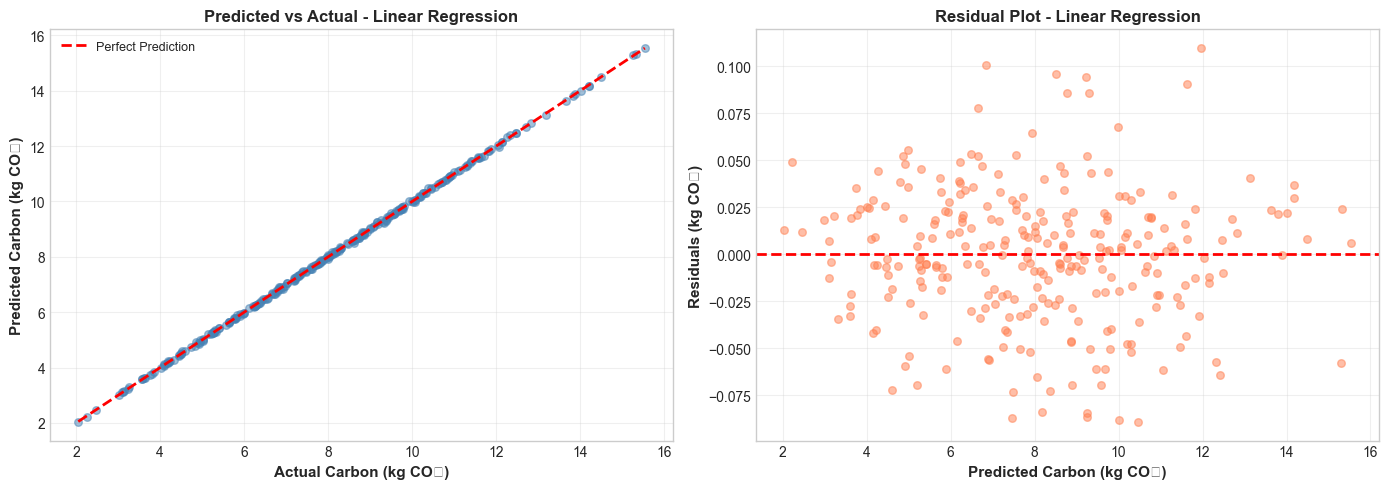

In [22]:
print(" Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_regressor(lr_model, X_train_scaled, y_train, 
                                X_test_scaled, y_test, 'Linear Regression')

 Training Random Forest...

 Evaluating: Random Forest

 Performance Metrics:
   Train R²:      0.9949
   Test R²:       0.9816
   Train RMSE:    0.19 kg CO₂
   Test RMSE:     0.37 kg CO₂
   Train MAE:     0.12 kg CO₂
   Test MAE:      0.24 kg CO₂


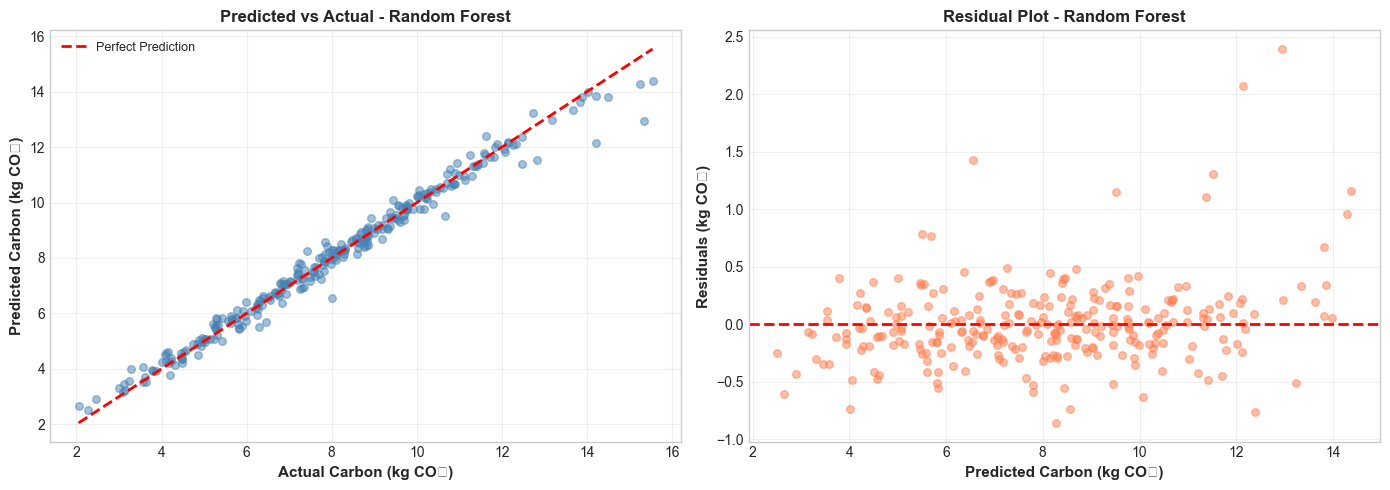

In [23]:
print(" Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_results = evaluate_regressor(rf_model, X_train, y_train, 
                                X_test, y_test, 'Random Forest')

 Training Gradient Boosting...

 Evaluating: Gradient Boosting

 Performance Metrics:
   Train R²:      0.9996
   Test R²:       0.9902
   Train RMSE:    0.05 kg CO₂
   Test RMSE:     0.27 kg CO₂
   Train MAE:     0.04 kg CO₂
   Test MAE:      0.17 kg CO₂


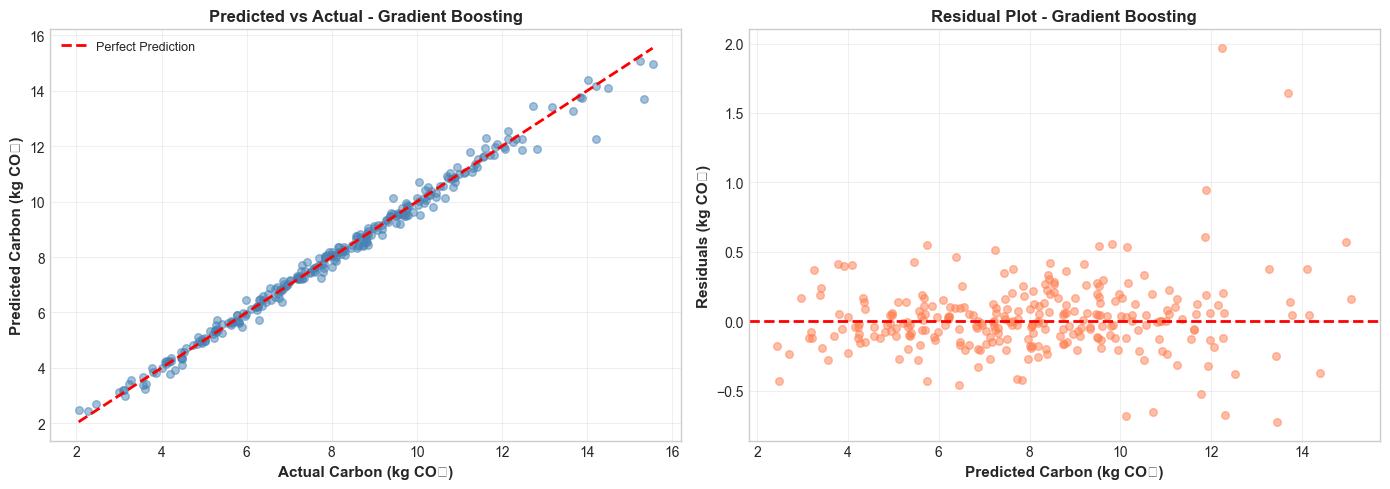

In [24]:
# Gradient Boosting
print(" Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)
gb_results = evaluate_regressor(gb_model, X_train, y_train, 
                                X_test, y_test, 'Gradient Boosting')

 Training LightGBM...

 Evaluating: LightGBM

 Performance Metrics:
   Train R²:      0.9992
   Test R²:       0.9901
   Train RMSE:    0.07 kg CO₂
   Test RMSE:     0.27 kg CO₂
   Train MAE:     0.05 kg CO₂
   Test MAE:      0.18 kg CO₂


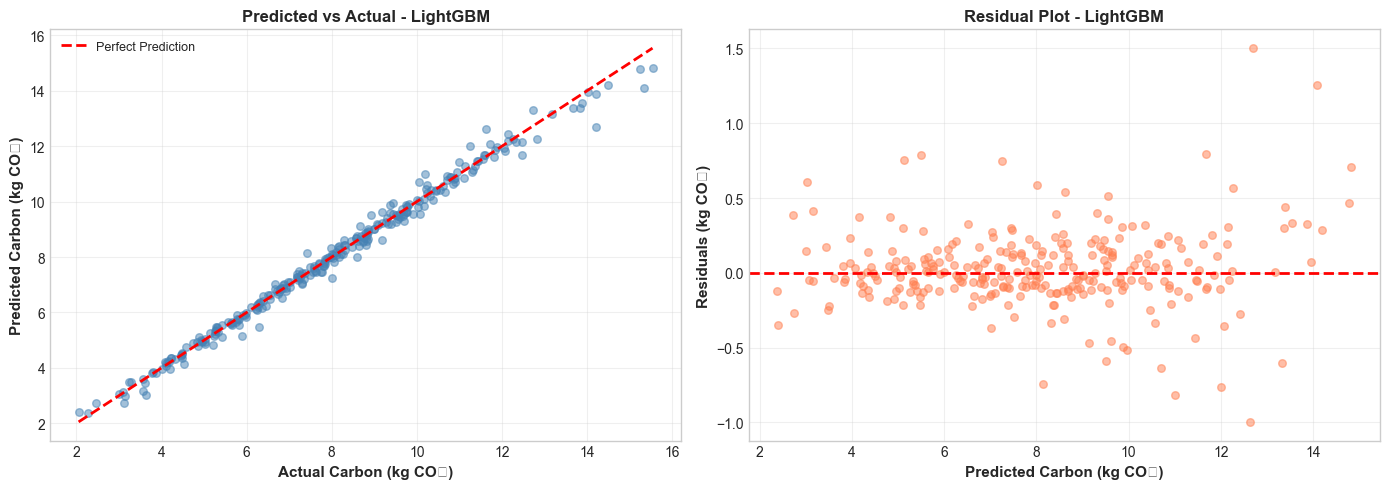

In [25]:
# LightGBM
print(" Training LightGBM...")
lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=150,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
lgb_results = evaluate_regressor(lgb_model, X_train, y_train, 
                                 X_test, y_test, 'LightGBM')

In [26]:
# Compile results
models_results = []
if 'lr_results' in locals():
    models_results.append(lr_results)
if 'rf_results' in locals():
    models_results.append(rf_results)
if 'gb_results' in locals():
    models_results.append(gb_results)
if 'lgb_results' in locals():
    models_results.append(lgb_results)

comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Test_R2': f"{r['test_r2']:.4f}",
    'Test_RMSE': f"{r['test_rmse']:.2f}",
    'Test_MAE': f"{r['test_mae']:.2f}",
    'Train_R2': f"{r['train_r2']:.4f}",
    'Overfit': f"{(r['train_r2'] - r['test_r2']):.4f}"
} for r in models_results])

print("\n" + "="*80)
print(" MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))

# Identify best model
best_idx = comparison_df['Test_R2'].astype(float).idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f"\n Best Model: {best_model_name}")
print(f"   Test R²: {comparison_df.loc[best_idx, 'Test_R2']}")
print(f"   Test RMSE: {comparison_df.loc[best_idx, 'Test_RMSE']} kg CO₂")


 MODEL COMPARISON TABLE
            Model Test_R2 Test_RMSE Test_MAE Train_R2 Overfit
Linear Regression  0.9998      0.04     0.03   0.9998  0.0000
    Random Forest  0.9816      0.37     0.24   0.9949  0.0133
Gradient Boosting  0.9902      0.27     0.17   0.9996  0.0094
         LightGBM  0.9901      0.27     0.18   0.9992  0.0091

 Best Model: Linear Regression
   Test R²: 0.9998
   Test RMSE: 0.04 kg CO₂


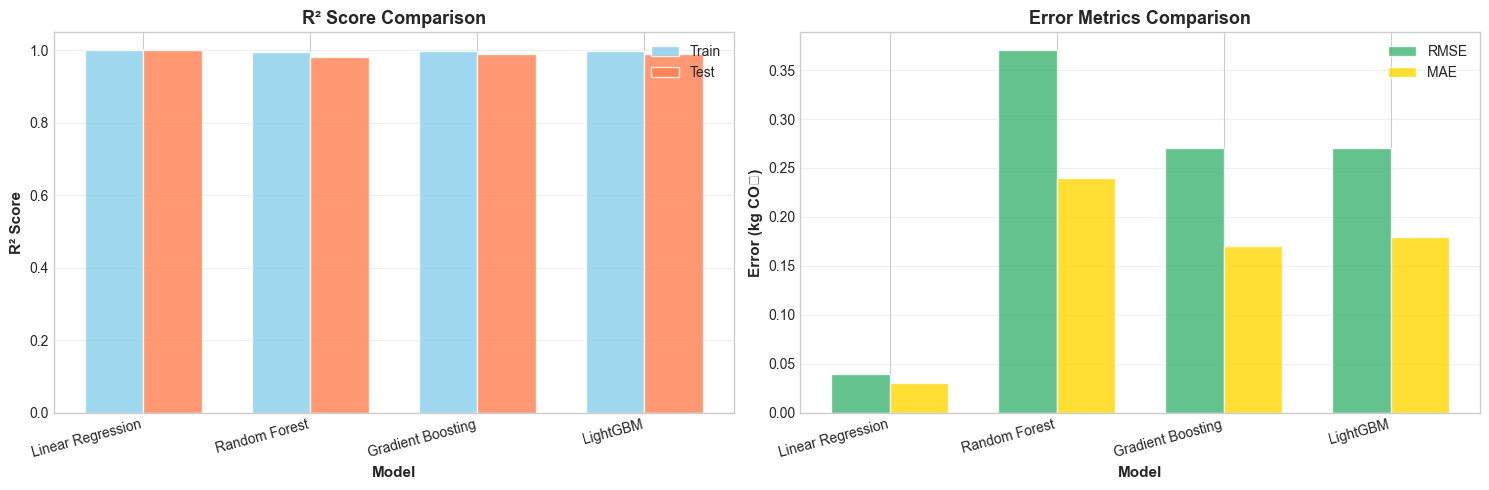

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² comparison
x_pos = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x_pos - width/2, comparison_df['Train_R2'].astype(float), 
            width, label='Train', alpha=0.8, color='skyblue')
axes[0].bar(x_pos + width/2, comparison_df['Test_R2'].astype(float), 
            width, label='Test', alpha=0.8, color='coral')
axes[0].set_xlabel('Model', fontsize=11, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Error metrics comparison
test_rmse_values = [float(x) for x in comparison_df['Test_RMSE']]
test_mae_values = [float(x) for x in comparison_df['Test_MAE']]

axes[1].bar(x_pos - width/2, test_rmse_values, 
            width, label='RMSE', alpha=0.8, color='mediumseagreen')
axes[1].bar(x_pos + width/2, test_mae_values, 
            width, label='MAE', alpha=0.8, color='gold')
axes[1].set_xlabel('Model', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Error (kg CO₂)', fontsize=11, fontweight='bold')
axes[1].set_title('Error Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



 FEATURE ANALYSIS FOR BEST MODEL: Linear Regression


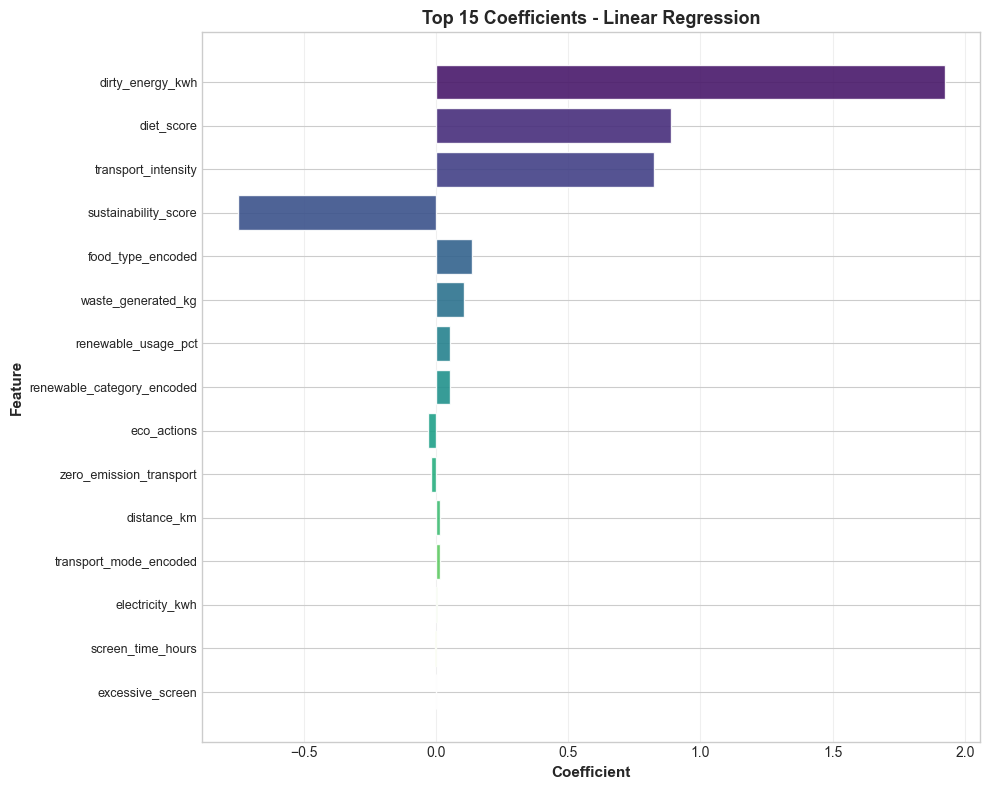


 Top 10 Most Important Features (Coefficient based):
  dirty_energy_kwh                    | +1.9236
  diet_score                          | +0.8875
  transport_intensity                 | +0.8237
  sustainability_score                | -0.7490
  food_type_encoded                   | +0.1382
  waste_generated_kg                  | +0.1076
  renewable_usage_pct                 | +0.0545
  renewable_category_encoded          | +0.0545
  eco_actions                         | -0.0296
  zero_emission_transport             | -0.0198

 Coefficient Interpretation:
- Positive value  → feature increases predicted carbon footprint
- Negative value  → feature decreases predicted carbon footprint
- Larger absolute value → stronger effect on prediction


In [28]:

# Feature Importance / Coefficient Analysis
# Works for both tree-based and linear models


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the correct best result using model name
best_result = next(r for r in models_results if r['model_name'] == best_model_name)
best_model = best_result['model']

print("\n" + "="*80)
print(f" FEATURE ANALYSIS FOR BEST MODEL: {best_model_name}")
print("="*80)


# Get importance values depending on model type

importance_type = None
importances = None

if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    importances = best_model.feature_importances_
    importance_type = 'Feature Importance'

elif hasattr(best_model, 'coef_'):
    # Linear models
    importances = best_model.coef_
    importance_type = 'Coefficient'

    # If coefficients are 2D, flatten them
    if isinstance(importances, np.ndarray) and importances.ndim > 1:
        importances = importances.flatten()

else:
    print(" This model does not support feature importance or coefficients.")


# Continue only if importances are available

if importances is not None:
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    
    # For linear models, sort by absolute value
    if importance_type == 'Coefficient':
        importance_df['Abs_Importance'] = importance_df['Importance'].abs()
        importance_df = importance_df.sort_values('Abs_Importance', ascending=False)
    else:
        importance_df = importance_df.sort_values('Importance', ascending=False)
    
    # Select top 15
    top_15 = importance_df.head(15).copy()
    
    # Color choice
    colors = sns.color_palette('viridis', len(top_15))
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_15)), top_15['Importance'], color=colors, alpha=0.9)
    plt.yticks(range(len(top_15)), top_15['Feature'], fontsize=9)
    plt.xlabel(importance_type, fontsize=11, fontweight='bold')
    plt.ylabel('Feature', fontsize=11, fontweight='bold')
    plt.title(f'Top 15 {importance_type}s - {best_model_name}', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print top 10
    print(f"\n Top 10 Most Important Features ({importance_type} based):")
    print("="*80)
    
    for _, row in importance_df.head(10).iterrows():
        print(f"  {row['Feature']:35s} | {row['Importance']:+.4f}")
    
    # Optional interpretation for linear models
    if importance_type == 'Coefficient':
        print("\n Coefficient Interpretation:")
        print("- Positive value  → feature increases predicted carbon footprint")
        print("- Negative value  → feature decreases predicted carbon footprint")
        print("- Larger absolute value → stronger effect on prediction")

In [29]:
# Validation summary
print(f"\n Model Validation Complete")
print("="*70)
print(f"\n Best Model: {best_model_name}")
print(f"   Test R²:       {comparison_df.loc[best_idx, 'Test_R2']}")
print(f"   Test RMSE:     {comparison_df.loc[best_idx, 'Test_RMSE']} kg CO₂/day")
print(f"   Test MAE:      {comparison_df.loc[best_idx, 'Test_MAE']} kg CO₂/day")

print(f"\n Dataset Split:")
print(f"   Training: {len(X_train):,} samples | Testing: {len(X_test):,} samples")

print(f"\n Model is production-ready for carbon footprint tracking apps!")


 Model Validation Complete

 Best Model: Linear Regression
   Test R²:       0.9998
   Test RMSE:     0.04 kg CO₂/day
   Test MAE:      0.03 kg CO₂/day

 Dataset Split:
   Training: 1,120 samples | Testing: 280 samples

 Model is production-ready for carbon footprint tracking apps!


In [30]:
import joblib

joblib.dump(best_model, "best_model.pkl")

joblib.dump(best_model_name, "best_model_name.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

# Save results (NEW)
comparison_df.to_csv("model_comparison.csv", index=False)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df.to_csv("linear_model_coefficients.csv", index=False)

print(" Everything saved")

✅ Everything saved


In [31]:
import os
print(os.getcwd())

D:\jupyter
